In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_PREP = REPO_ROOT / "data" / "prepared"

# Filenames (edit ONLY these if your filenames differ)
data_file = DATA_PREP / "S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv"
classes_file = DATA_PREP / "LUCAS_2018_Copernicus_attributes_cropmap_level1-2_FROM_EXPORTS.csv"

In [3]:
class_table = pd.read_csv(classes_file)
print(class_table)

# Load class legend table 

classes_L1 = class_table["level_1"].dropna().unique().tolist()
classes_L2 = class_table["level_2"].dropna().unique().tolist()

df = pd.read_csv(data_file, dtype={'level_1': int, 'level_2': int})
print(f"Loaded dataset with shape {df.shape}")

       POINT_ID  stratum  LC1   LU1  level_1  level_2
0      47242864        1  B11  U111      200      211
1      47322804        1  B11  U111      200      211
2      47602810        1  B11  U111      200      211
3      47622814        1  B11  U111      200      211
4      47642818        1  B11  U111      200      211
...         ...      ...  ...   ...      ...      ...
30929  36503184        1  E20  U111      500      500
30930  36643156        1  E20  U111      500      500
30931  36703150        1  E20  U111      500      500
30932  36503170        1  F40  U111      200      290
30933  36883144        1  F40  U112      200      290

[30934 rows x 6 columns]
Loaded dataset with shape (1743815, 46)


In [4]:
#official Level-2 set:
L2_official = {211,212,213,214,215,216,217,218,219,221,222,223,230,231,232,233,240,250,290}

# remove non crop labled data
bad_L1 = {100,300,500,600}
classes_L2 = [c for c in classes_L2 if c in L2_official]

print(f"Classes in level_1: {classes_L1}")
print(f"Classes in level_2: {classes_L2}")
df.head()

Classes in level_1: [200, 500, 300, 600, 100]
Classes in level_2: [211, 212, 213, 214, 215, 216, 218, 219, 221, 222, 223, 231, 232, 233, 230, 240, 250, 290]


,POINT_ID,stratum,level_1,level_2,VH_20180101,VH_20180111,VH_20180121,VH_20180131,VH_20180210,VH_20180220,...,VV_20180421,VV_20180501,VV_20180511,VV_20180521,VV_20180531,VV_20180610,VV_20180620,VV_20180630,VV_20180710,VV_20180720
0,47242864,1,200,211,-17.729420,-20.325294,-19.684908,-20.850082,-20.764990,-23.271540,...,-15.297538,-14.691077,-11.272779,-13.191196,-13.326975,-9.991315,-12.012024,-11.717594,-11.879456,-13.265092
1,47242864,1,200,211,-17.629759,-20.395664,-19.362911,-20.440153,-21.169271,-23.260570,...,-13.002155,-14.203595,-10.049500,-11.750811,-12.224334,-8.608410,-12.611928,-11.085283,-11.449447,-12.753875
2,47322804,1,200,211,-16.761300,-16.439291,-19.003990,-20.409580,-22.091795,-21.210240,...,-16.568722,-17.411484,-14.883723,-14.744152,-14.379078,-15.570848,-14.374341,-12.383735,-9.408920,-11.391636
3,47322804,1,200,211,-16.949911,-17.447950,-18.359556,-20.564657,-23.349674,-21.620611,...,-16.051369,-18.421627,-15.666489,-14.994968,-14.695726,-15.396705,-13.609975,-12.813351,-10.927353,-10.113678
4,47322804,1,200,211,-16.443756,-16.525919,-18.132175,-20.206577,-23.046797,-22.294617,...,-15.959276,-18.084450,-14.830488,-15.250996,-14.610595,-15.430483,-15.022743,-12.809982,-10.214397,-10.957893


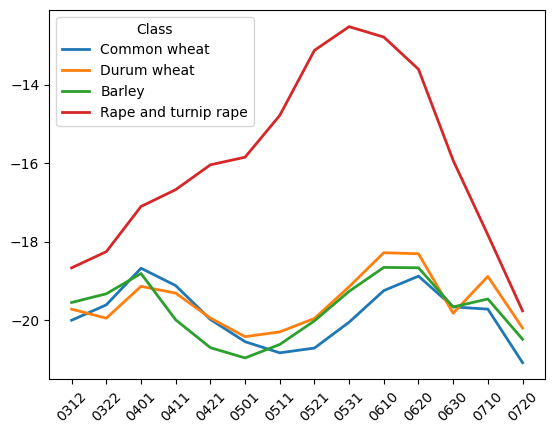

In [11]:
band_columns = df.columns[11:25]
band_labels = band_columns.str[7:]
target_classes = [211, 212, 213, 232]
class_colors = {211: 'tab:blue', 212: 'tab:orange', 213: 'tab:green', 232: 'tab:red'}
class_names = {
    211: 'Common wheat',
    212: 'Durum wheat',
    213: 'Barley',
    214: 'Rye',
    215: 'Oats',
    216: 'Maize',
    217: 'Rice',
    218: 'Triticale',
    219: 'Other cereals',
    221: 'Potatoes',
    222: 'Sugar beet',
    223: 'Other roots crops',
    230: 'Other non permanent industrial crops',
    231: 'Sunflower',
    232: 'Rape and turnip rape',
    233: 'Soya',
    240: 'Dry pulses, vegetables and flowers',
    250: 'Other fodder crops (excl. temp. grasslands)',
    290: 'Bare arable land',
}
x = range(len(band_labels))

plt.xticks(x, band_labels, rotation=45)

for target_class in target_classes:
    class_subset = df[df.level_2 == target_class].loc[:, band_columns]
    mean_curve = class_subset.mean()
    color = class_colors[target_class]
    plt.plot(x, mean_curve, color=color, linewidth=2, label=class_names.get(target_class, str(target_class)))

plt.legend(title='Class')
plt.show()  